# AAV9 fitting protocol, Potts GT -- manual playground, GT-vs-sim overlay, population
# size tables, ProfileMLP recovery

Replays sections 5, 6, 7 of `AAV9_fitting_protocol.ipynb` (manual playground -> simulated log
enrichment, GT-score-vs-simulation overlay, ProfileMLP held-out recovery) -- same section
numbers, same convention as the existing `AAV2_fitting_protocol.ipynb`/
`AAV5_fitting_protocol.ipynb` siblings that replay these same sections for a different AAV
dataset. Here it's the same `aav9.csv`, but a different GT: `F_potts`/`J_potts` (joint
ridge/Potts regression fit directly on `aav9.csv`, `AAV9_potts_regression.ipynb`) instead of
the naive per-cell GT `AAV9_fitting_protocol.ipynb` itself uses.

Skips parts 1 (repeatability) and 2 (hyperparameter search) -- both live in
`AAV9_fitting_protocol.ipynb` and are about calibrating `mu`/`T_viab`/`noise_viab`/`D`, which
this notebook reuses as-is (same baseline: `mu=50`, `T_viab=0.8`, `noise_viab=0.5`, `D=1e9`),
not re-derives (see `CLAUDE.md`'s note on why `AAV9_fitting_protocol.ipynb` wasn't swapped to
the Potts GT). Lighter-weight cousin of `AAV9_potts_GT_score_study.ipynb` (sections 2/2b/5/6
only, no part 7, no population tables) -- this notebook is the fuller replay, plus the new
addition asked for here: DataFrame tables of population size (molecule/read counts, number of
variants still detected) at each `Protocol` checkpoint, for a real AAV9 library run scored with
this GT.

## 0. Setup

In [50]:
import sys, os

# This notebook lives in "Modelization_V1/notebooks/aav_viability_test/", two levels below
# analysisV1.py / sequence_classesV1.py -- same sys.path convention as AAV9_fitting_protocol.ipynb.
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from tqdm.auto import tqdm

from analysisV1 import AA_LABELS, pearson, count_over_threshold, number_of_seq_threshold, proportion_above_threshold
from sequence_classesV1 import ProtocolV3
from initialize_weights import load_F_viab_aav9_potts, load_J_viab_aav9_potts, NUM_AMINO_ACIDS, NUM_POSITIONS

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

message = "AAV9 fitting protocol, Potts GT, 1.0"


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Real AAV9 data: sequences + real `target`

In [51]:
df = pd.read_csv("aav9.csv")
print(f"{len(df):,} variants, columns: {list(df.columns)}")

lengths = df["sequence"].str.len().unique()
assert len(lengths) == 1, f"expected a single sequence length, got {lengths}"
assert int(lengths[0]) == NUM_POSITIONS

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes   = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix  = lut[seq_bytes].reshape(len(df), NUM_POSITIONS)
real_target = df["target"].to_numpy()

sequences = jnp.asarray(seq_matrix)
d0        = sequences.shape[0]

print(f"seq_matrix shape: {seq_matrix.shape}  (num_sequences, num_positions)")
print(f"d0 = {d0:,} real AAV9 library sequences")


68,776 variants, columns: ['sequence', 'target', 'error']
seq_matrix shape: (68776, 7)  (num_sequences, num_positions)
d0 = 68,776 real AAV9 library sequences


## 2. Ground-truth weights + baseline protocol config

`F_viab`/`J_viab` are the joint Potts-regression GT (`AAV9_potts_regression.ipynb`), loaded via
`load_F_viab_aav9_potts`/`load_J_viab_aav9_potts` -- already in the right amino-acid/position
convention for `seq_matrix` above.

Same baseline config as `AAV9_fitting_protocol.ipynb` (`mu=50`, `T_viab=0.8`, `noise_viab=0.5`,
`D=1e9`, `RHO_REF=1e-3`, `N0=N1*10`) -- kept identical so results are directly comparable to
that notebook's naive-GT run, not confounded by a different operating point.

In [80]:
F_viab = load_F_viab_aav9_potts()
J_viab = load_J_viab_aav9_potts()

F_sel = jnp.zeros_like(F_viab)
J_sel = jnp.zeros_like(J_viab)

RHO_REF          = 1e-3
MU_FIXED         = 500
T_VIAB_FIXED     = 0.8
NOISE_VIAB_FIXED = 0.5
D_FIXED          = 1e9
DILUTION_FACTOR  = 10
T_SEL_FIXED      = 1.0   # unused by target1, kept at the project default
eps              = 1

N1_FIXED = MU_FIXED * d0 / RHO_REF
N0_FIXED = N1_FIXED * 150

protocol = ProtocolV3(multinomialNGS=True, N0=N0_FIXED, N1=N1_FIXED,
        dilution_factor=DILUTION_FACTOR, sequences=sequences, D=D_FIXED,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=NOISE_VIAB_FIXED, noise_sel=0.0, T_sel=T_SEL_FIXED, T_viab=T_VIAB_FIXED,
        )

print(f"mu = {protocol._rho * protocol.N1 / d0:.2f}   N1={N1_FIXED:.3e}   N0={N0_FIXED:.3e}")
print(f"D/d0 (reads/sequence at baseline) = {D_FIXED / d0:.1f}")


mu = 500.00   N1=3.439e+10   N0=5.158e+12
D/d0 (reads/sequence at baseline) = 14540.0


### 2a. `viability_target1` helper

Same helper as `AAV9_fitting_protocol.ipynb`: runs one `loop_DE()` round and returns
`target1 = log((lambda2p+eps)/(lambda0p+eps))`, the viability log-enrichment estimated from
simulated NGS reads only. Resets `lambda0` first, since `loop_DE()` depletes it in place.

In [53]:
def viability_target1(protocol, eps=eps):
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
    _bio_row, ngs_row = protocol.loop_DE()
    lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
    return np.log((lambda2p + eps) / (lambda0p + eps))


## 2b. GT score distribution + `R_REAL`

`viab_score_GT = compute_score(F_viab, J_viab)` -- the deterministic F+J score for every real
sequence, no protocol simulation, no noise at all. `R_REAL = pearson(real_target, viab_score_GT)`
is the reference correlation everything downstream is compared against.

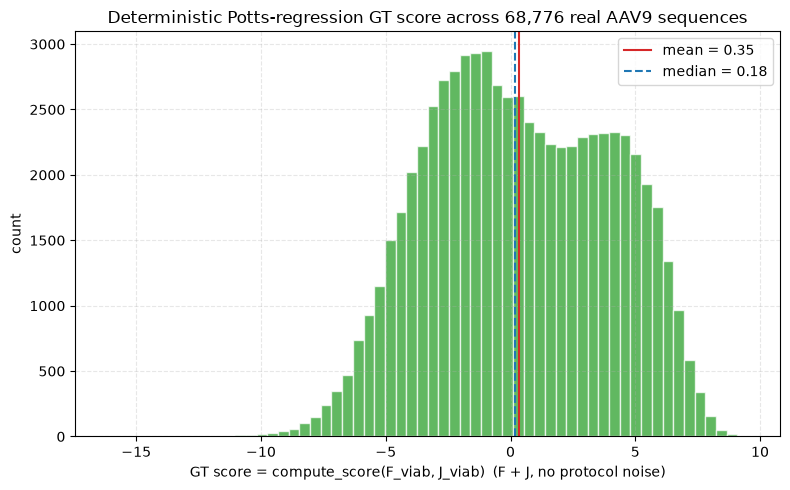

GT score: min=-16.16  max=9.52  mean=0.35  std=3.62
R_REAL = r(real aav9 target, deterministic GT score) = 0.889


In [54]:
viab_score_GT = np.asarray(protocol.compute_score(F_viab, J_viab))
R_REAL = pearson(real_target, viab_score_GT)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(viab_score_GT, bins=60, color="tab:green", alpha=0.75, edgecolor="white")
ax.axvline(viab_score_GT.mean(), color="tab:red", linestyle="-", label=f"mean = {viab_score_GT.mean():.2f}")
ax.axvline(np.median(viab_score_GT), color="tab:blue", linestyle="--", label=f"median = {np.median(viab_score_GT):.2f}")
ax.set_xlabel("GT score = compute_score(F_viab, J_viab)  (F + J, no protocol noise)")
ax.set_ylabel("count")
ax.set_title(f"Deterministic Potts-regression GT score across {d0:,} real AAV9 sequences")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"GT score: min={viab_score_GT.min():.2f}  max={viab_score_GT.max():.2f}  "
      f"mean={viab_score_GT.mean():.2f}  std={viab_score_GT.std():.2f}")
print(f"R_REAL = r(real aav9 target, deterministic GT score) = {R_REAL:.3f}")


## 5. Manual playground: tweak hyperparameters and weights by hand

Edit the block at the top of the cell below (hyperparameters, and/or `F_VIAB_MANUAL`/
`J_VIAB_MANUAL`) and re-run -- it always sets `protocol`'s full state from these variables, so
nothing is left over between runs. Defaults reuse the baseline config from section 2, with
`F_VIAB_MANUAL`/`J_VIAB_MANUAL` set to the Potts GT.

In [ ]:
"""
RHO_REF          = 1e-3
MU_FIXED         = 50
T_VIAB_FIXED     = 0.8
NOISE_VIAB_FIXED = 0.5
D_FIXED          = 1e9
DILUTION_FACTOR  = 10
T_SEL_FIXED      = 1.0   # unused by target1, kept at the project default
eps              = 1.0

N1_FIXED = MU_FIXED * d0 / RHO_REF
N0_FIXED = N1_FIXED * 10
"""

# ---- Edit these, then re-run this cell ----
MU_MANUAL         = 50
T_VIAB_MANUAL     = 1.3
NOISE_VIAB_MANUAL = NOISE_VIAB_FIXED
D_MANUAL          = D_FIXED
# --------------------------------------------

protocol.N1          = float(MU_MANUAL * d0 / RHO_REF)*10
protocol.N0          = float(protocol.N1 * 150)
protocol._T_viab     = float(T_VIAB_MANUAL)
protocol.noise_viab  = float(NOISE_VIAB_MANUAL)
protocol.D           = float(D_MANUAL)

target1_manual   = viability_target1(protocol)
r_manual         = pearson(target1_manual, real_target)
frac_zero_manual = float(np.mean(target1_manual == 0.0))

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(min(real_target.min(), target1_manual.min()),
                    max(real_target.max(), target1_manual.max()), 60)
ax.hist(real_target,    bins=bins, alpha=0.55, density=True, color="tab:orange", label="real aav9 target")
ax.hist(target1_manual, bins=bins, alpha=0.55, density=True, color="tab:blue",   label="simulated target1")
ax.set_xlabel("log enrichment")
ax.set_ylabel("density")
ax.set_title(f"mu={MU_MANUAL:.3g}  T_viab={T_VIAB_MANUAL:.3g}  noise_viab={NOISE_VIAB_MANUAL:.3g}  D={D_MANUAL:.3g}\n"
             f"r(sim, real)={r_manual:.3f}   R_REAL={R_REAL:.3f}   frac(target1=0)={frac_zero_manual:.3f}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


### 5a. Population size through the pipeline (new)

`viability_target1(protocol)` above just ran one full `loop_DE()` round on the real AAV9
library scored with the Potts GT -- `protocol.lambda0/lambda0p/lambda2/lambda2p/lambda3/lambda3p/lambda4`
are now populated for that run. Two DataFrames, reusing `analysisV1.number_of_seq_threshold`/
`proportion_above_threshold` (already built for exactly this):

- **Summary** : total molecule/read count and how many of the `d0` real variants are still
  detected (count >= 1) at each checkpoint.
- **Detection thresholds** : same idea, swept over a few higher count thresholds (>=1, >=10,
  >=100, >=1000) -- how concentrated the surviving population gets deeper into the pipeline.
- **Relative abundance** : how many variants remain above a given % of that checkpoint's total
  pool (0.1%, 0.01%, 0.001%) -- population size in RELATIVE terms, not just raw counts.

In [65]:
lambdas_dict = {
    "lambda0 (initial library)":          protocol.lambda0,
    "lambda0p (NGS reads, checkpoint 1)":  protocol.lambda0p,
    "lambda2 (post-viability capsids)":    protocol.lambda2,
    "lambda2p (NGS reads, checkpoint 2)":  protocol.lambda2p,
    "lambda3 (post-selectivity)":          protocol.lambda3,
    "lambda3p (NGS reads, checkpoint 3)":  protocol.lambda3p,
    "lambda4 (bacterial amplification)":   protocol.lambda4,
}
lambdas_np = {name: np.asarray(arr) for name, arr in lambdas_dict.items()}

summary_df = pd.DataFrame({
    "total (sum)":              [arr.sum() for arr in lambdas_np.values()],
    "n_variants_detected (>=1)": [count_over_threshold(arr, 1.0) for arr in lambdas_np.values()],
    "fraction_of_library":      [count_over_threshold(arr, 1.0) / d0 for arr in lambdas_np.values()],
}, index=list(lambdas_np.keys()))
summary_df.index.name = "checkpoint"

threshold_table = number_of_seq_threshold(lambdas_np, thresholds=[1, 10, 100, 1000])
abundance_table = proportion_above_threshold(lambdas_np, thresholds_pct=[0.1, 0.01, 0.001])

print(f"Population size through the pipeline (Potts GT, mu={MU_MANUAL:.3g}, d0={d0:,} real AAV9 variants):")
summary_df


Population size through the pipeline (Potts GT, mu=50, d0=68,776 real AAV9 variants):


,total (sum),n_variants_detected (>=1),fraction_of_library
checkpoint,,,
lambda0 (initial library),4.642379e+11,68776,1.000000
"lambda0p (NGS reads, checkpoint 1)",9.999635e+08,68776,1.000000
lambda2 (post-viability capsids),2.717929e+11,68776,1.000000
"lambda2p (NGS reads, checkpoint 2)",9.999818e+08,68551,0.996729
lambda3 (post-selectivity),2.446147e+11,68775,0.999985
"lambda3p (NGS reads, checkpoint 3)",9.999807e+08,68555,0.996787
lambda4 (bacterial amplification),5.158197e+11,68760,0.999767


In [66]:
print("Number of variants with count >= threshold, per checkpoint:")
threshold_table


Number of variants with count >= threshold, per checkpoint:


,1.0,10.0,100.0,1000.0
lambda,,,,
lambda0 (initial library),68776,68776,68776,68776
"lambda0p (NGS reads, checkpoint 1)",68776,68776,68776,68776
lambda2 (post-viability capsids),68776,68772,68716,67816
"lambda2p (NGS reads, checkpoint 2)",68551,65674,52233,32770
lambda3 (post-selectivity),68775,68770,68706,67686
"lambda3p (NGS reads, checkpoint 3)",68555,65650,52200,32776
lambda4 (bacterial amplification),68760,68760,68747,68353


In [67]:
print("Number of variants above a given % of that checkpoint's total pool:")
abundance_table


Number of variants above a given % of that checkpoint's total pool:


,> 0.1%,> 0.01%,> 0.001%
lambda,,,
lambda0 (initial library),0,0,68776
"lambda0p (NGS reads, checkpoint 1)",0,0,68776
lambda2 (post-viability capsids),3,2353,16662
"lambda2p (NGS reads, checkpoint 2)",3,2359,16659
lambda3 (post-selectivity),3,2352,16661
"lambda3p (NGS reads, checkpoint 3)",3,2353,16660
lambda4 (bacterial amplification),3,2354,16662


## 6. Overlay: GT score vs the manual playground's simulated log enrichment

`viab_score_GT` (section 2b, deterministic F+J, no noise) vs `target1_manual` (section 5, one
stochastic `loop_DE()` run at the hand-picked hyperparameters above).

r(simulated target1, GT score) = 0.997   (unaffected by the T_viab rescaling -- Pearson r is invariant to dividing by a positive constant)
R_REAL = 0.889   (target this should land near, per AAV9_fitting_protocol.ipynb's part 2 search)


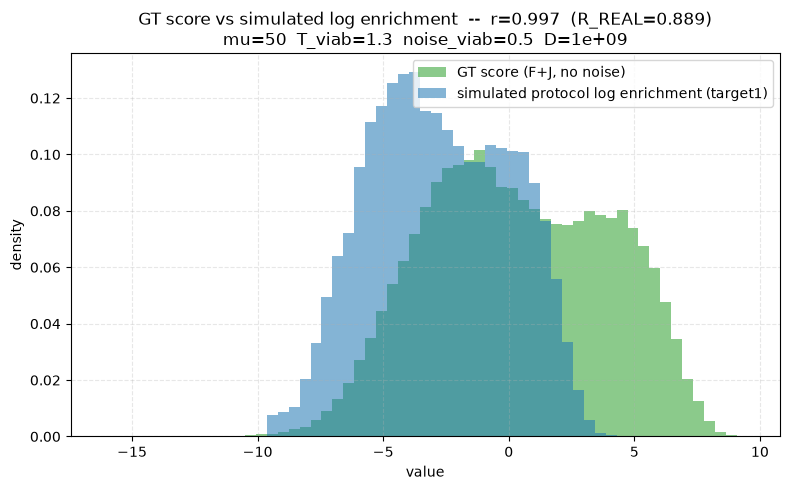

In [68]:
r_manual_vs_GT = pearson(target1_manual, viab_score_GT)
print(f"r(simulated target1, GT score) = {r_manual_vs_GT:.3f}   "
      f"(unaffected by the T_viab rescaling -- Pearson r is invariant to dividing by a positive constant)")
print(f"R_REAL = {R_REAL:.3f}   (target this should land near, per AAV9_fitting_protocol.ipynb's part 2 search)")

fig, ax = plt.subplots(figsize=(8, 5))
bins_score = np.linspace(min(viab_score_GT.min(), target1_manual.min()),
                          max(viab_score_GT.max(), target1_manual.max()), 60)
ax.hist(viab_score_GT,  bins=bins_score, alpha=0.55, density=True, color="tab:green", label="GT score (F+J, no noise)")
ax.hist(target1_manual, bins=bins_score, alpha=0.55, density=True, color="tab:blue",  label="simulated protocol log enrichment (target1)")
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.set_title(f"GT score vs simulated log enrichment  --  r={r_manual_vs_GT:.3f}  (R_REAL={R_REAL:.3f})\n"
             f"mu={MU_MANUAL:.3g}  T_viab={T_VIAB_MANUAL:.3g}  noise_viab={NOISE_VIAB_MANUAL:.3g}  D={D_MANUAL:.3g}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


## 8. Cross-packaging noise source

Adds one more simulated noise source on top of the baseline `ProtocolV3` above (same Potts GT,
same baseline hyperparameters), from `lib/cross_packaging_draft.py`:

- **`ProtocolCrossPackagingBackground`** : a non-viable variant co-transfected with a functional
  one in the same HEK cell can erroneously package that neighbor's DNA -- modeled as an
  aggregate leakage term added to every sequence's Poisson production rate
  (`cross_packaging_rate` x the median rate among transfected sequences).

Hallucination (`ProtocolWithHallucination`) is deliberately left out for now -- the value
currently set for `HALLUCINATION_RATE` in `AAV9_cross_packaging_and_hallucination_impact.ipynb`
(0.17) doesn't match the empirical rate documented elsewhere in the project (69/74464 ≈ 0.09%,
from `new_variant_appearance_analysis.ipynb`) and gives a much larger, likely miscalibrated
impact -- to revisit once that's sorted out.


In [73]:
from cross_packaging_draft import ProtocolCrossPackagingBackground

CROSS_PACKAGING_RATE = 0.02   # fraction of the "healthy neighbor" median rate leaked to every sequence


N1          = float(MU_MANUAL * d0 / RHO_REF)
N0          = float(N1 * 150)
_T_viab     = float(T_VIAB_MANUAL)
noise_viab  = float(NOISE_VIAB_MANUAL)
D           = float(D_MANUAL)

BASE_KWARGS = dict(
    multinomialNGS=True, N0=N0, N1=N1, dilution_factor=DILUTION_FACTOR,
    sequences=sequences, D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=noise_viab, noise_sel=0.0, T_sel=T_SEL_FIXED, T_viab=_T_viab,
)

cp_variants = {
    "baseline":         ProtocolV3(**BASE_KWARGS),
    "cross-packaging":  ProtocolCrossPackagingBackground(**BASE_KWARGS, cross_packaging_rate=CROSS_PACKAGING_RATE),
}

cp_results = {}
for name, cp_protocol in cp_variants.items():
    t1 = viability_target1(cp_protocol)
    cp_results[name] = dict(
        target1=t1,
        r_sim_real=pearson(t1, real_target),
        r_sim_gt=pearson(t1, viab_score_GT),
        frac_zero=float(np.mean(t1 == 0.0)),
    )
    print(f"{name:18s}  r(sim,real)={cp_results[name]['r_sim_real']:.3f}  "
          f"r(sim,GT)={cp_results[name]['r_sim_gt']:.3f}  frac(target1=0)={cp_results[name]['frac_zero']:.3f}")


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

baseline            r(sim,real)=0.889  r(sim,GT)=0.997  frac(target1=0)=0.000


cross-packaging     r(sim,real)=0.897  r(sim,GT)=0.991  frac(target1=0)=0.000


### 8a. Simulated `target1` vs real `target` -- one panel per variant

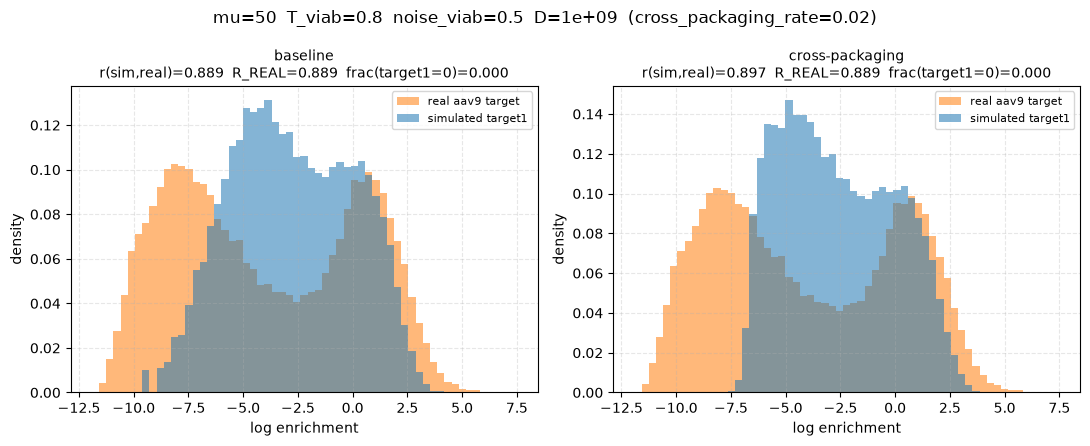

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
bins_real_cp = np.linspace(
    min(real_target.min(), *(r["target1"].min() for r in cp_results.values())),
    max(real_target.max(), *(r["target1"].max() for r in cp_results.values())),
    60,
)

for ax, (name, r) in zip(axes, cp_results.items()):
    ax.hist(real_target,  bins=bins_real_cp, alpha=0.55, density=True, color="tab:orange", label="real aav9 target")
    ax.hist(r["target1"], bins=bins_real_cp, alpha=0.55, density=True, color="tab:blue",   label="simulated target1")
    ax.set_title(f"{name}\nr(sim,real)={r['r_sim_real']:.3f}  R_REAL={R_REAL:.3f}  frac(target1=0)={r['frac_zero']:.3f}",
                 fontsize=10)
    ax.set_xlabel("log enrichment")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.3)

fig.suptitle(f"mu={MU_FIXED}  T_viab={T_VIAB_FIXED}  noise_viab={NOISE_VIAB_FIXED}  D={D_FIXED:.0e}  "
             f"(cross_packaging_rate={CROSS_PACKAGING_RATE})")
fig.tight_layout()
plt.show()


### 8b. Simulated `target1` vs deterministic GT score -- one panel per variant

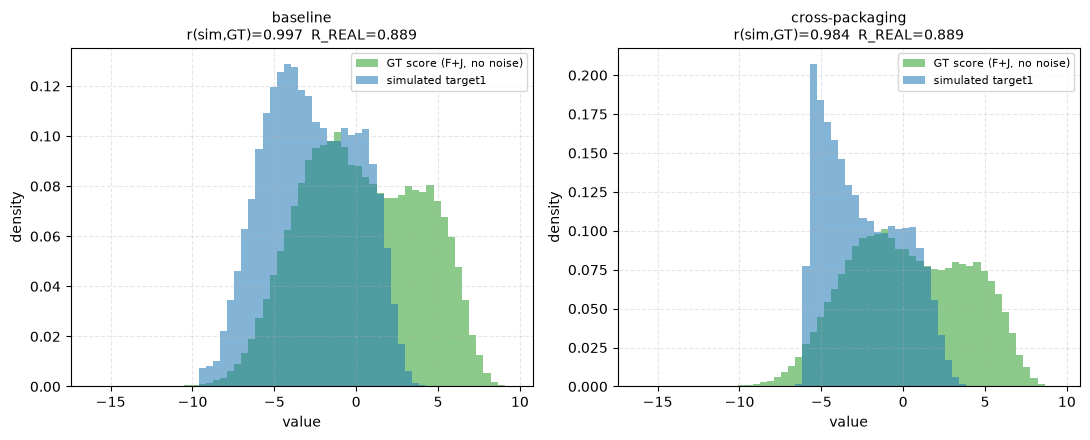

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
bins_gt_cp = np.linspace(
    min(viab_score_GT.min(), *(r["target1"].min() for r in cp_results.values())),
    max(viab_score_GT.max(), *(r["target1"].max() for r in cp_results.values())),
    60,
)

for ax, (name, r) in zip(axes, cp_results.items()):
    ax.hist(viab_score_GT, bins=bins_gt_cp, alpha=0.55, density=True, color="tab:green", label="GT score (F+J, no noise)")
    ax.hist(r["target1"],  bins=bins_gt_cp, alpha=0.55, density=True, color="tab:blue",  label="simulated target1")
    ax.set_title(f"{name}\nr(sim,GT)={r['r_sim_gt']:.3f}  R_REAL={R_REAL:.3f}", fontsize=10)
    ax.set_xlabel("value")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.3)

fig.tight_layout()
plt.show()


### 8c. Summary

In [72]:
cp_summary_df = pd.DataFrame({
    name: {"r(sim, real)": r["r_sim_real"], "r(sim, GT)": r["r_sim_gt"], "frac(target1=0)": r["frac_zero"]}
    for name, r in cp_results.items()
}).T
cp_summary_df.loc["R_REAL (reference)"] = [R_REAL, np.nan, np.nan]
cp_summary_df


,"r(sim, real)","r(sim, GT)",frac(target1=0)
baseline,0.888611,0.996799,0.0
cross-packaging,0.897467,0.984475,0.0
R_REAL (reference),0.888784,NaN,NaN
